<a href="https://www.kaggle.com/code/beyzadurduu/xgboots-cc-fraud-detection-2?scriptVersionId=354976087" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mlg-ulb/creditcardfraud/creditcard.csv


In [2]:
df=pd.read_csv("/kaggle/input/datasets/mlg-ulb/creditcardfraud/creditcard.csv")

In [3]:
df.head(3)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


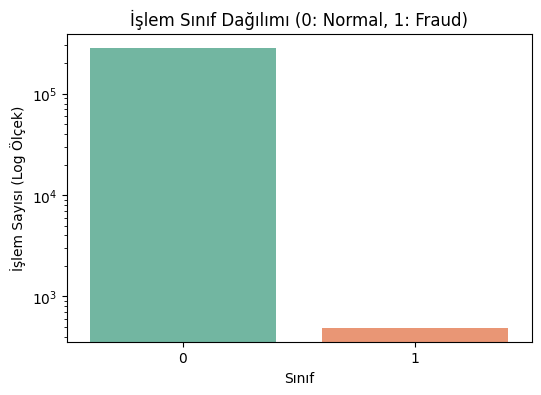

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df, hue='Class', palette='Set2', legend=False)
plt.title('İşlem Sınıf Dağılımı (0: Normal, 1: Fraud)')
plt.yscale('log') # Çok dengesiz olduğu için logaritmik ölçek kullanıyoruz
plt.xlabel('Sınıf')
plt.ylabel('İşlem Sayısı (Log Ölçek)')
plt.show()

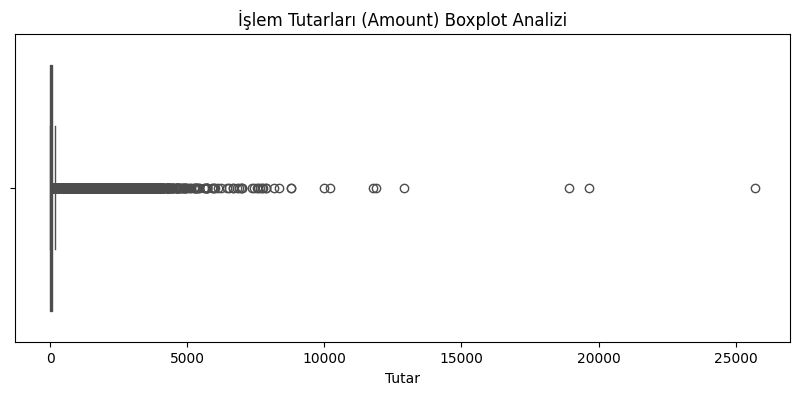

In [5]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Amount'], color='orange')
plt.title('İşlem Tutarları (Amount) Boxplot Analizi')
plt.xlabel('Tutar')
plt.show()

In [6]:
#MODELİ İNCELEDİĞİMİZDE AYKIRI DEĞERLER OLDUĞUNU GÖRÜYORUZ.STANDART SCALER YERİNE RobustScaler SEÇİLMELİDİR.

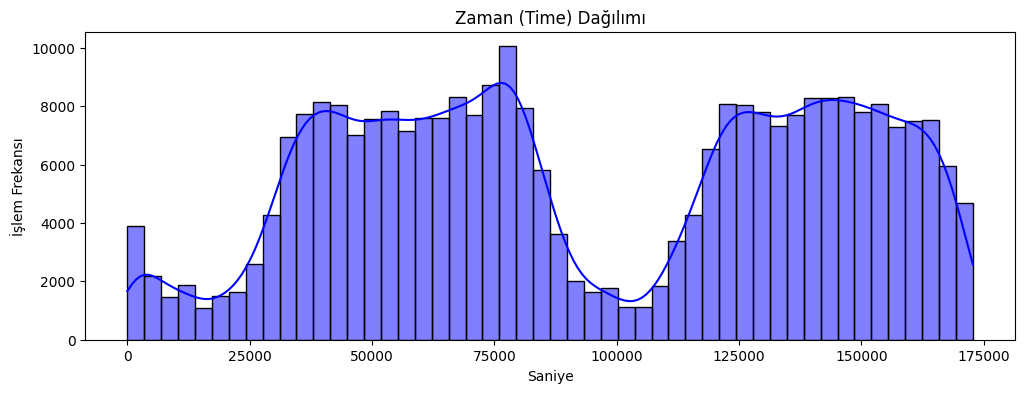

In [7]:
plt.figure(figsize=(12, 4))
sns.histplot(df['Time'], bins=50, kde=True, color='blue')
plt.title('Zaman (Time) Dağılımı')
plt.xlabel('Saniye')
plt.ylabel('İşlem Frekansı')
plt.show()

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [9]:
#categorik veri yok o yüzden one hot encoding yapmayacağız.

In [10]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [11]:
#eksik veri de yok

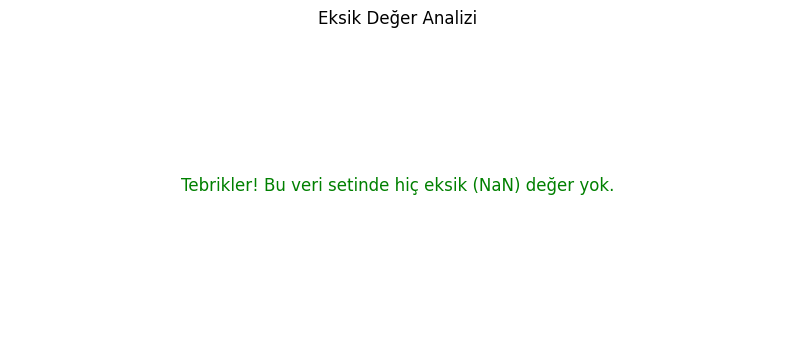

In [12]:
missing_values = df.isnull().sum()

# Sadece eksik değeri olan sütunları filtreleme (Bu veri setinde hepsi 0 çıkacaktır)
missing_values = missing_values[missing_values > 0]

plt.figure(figsize=(10, 4))

if len(missing_values) > 0:
    sns.barplot(x=missing_values.index, y=missing_values.values, palette='viridis')
    plt.title('Sütunlardaki Eksik Değer Sayıları')
    plt.xticks(rotation=45)
    plt.xlabel('Sütunlar')
    plt.ylabel('Eksik Veri Sayısı')
else:
    # Veri setinde hiç eksik değer yoksa kullanıcıyı bilgilendiren bir görsel veya yazı
    plt.text(0.5, 0.5, 'Tebrikler! Bu veri setinde hiç eksik (NaN) değer yok.', 
             horizontalalignment='center', verticalalignment='center', fontsize=12, color='green')
    plt.title('Eksik Değer Analizi')
    plt.axis('off')

plt.show()

In [13]:
X = df.drop('Class', axis=1)
y = df['Class']

In [14]:
from sklearn.model_selection import train_test_split
print("Veri eğitim ve test olarak bölünüyor...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

Veri eğitim ve test olarak bölünüyor...


In [15]:
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_weight = neg_count / pos_count
print(f"Hesaplanan scale_pos_weight (Ağırlık) oranı: {scale_weight:.2f}")

Hesaplanan scale_pos_weight (Ağırlık) oranı: 577.29


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import average_precision_score
from imblearn.pipeline import Pipeline as ImbPipeline
import xgboost as xgb
scaler = RobustScaler()
scaler.set_output(transform="pandas")

pipeline = ImbPipeline([
    ('scaler', scaler),
    ('model', xgb.XGBClassifier(
        n_estimators=1000,
        max_depth=5,
        learning_rate=0.05,
        scale_pos_weight=scale_weight,
        eval_metric='aucpr',
        early_stopping_rounds=40,
        random_state=42,
        n_jobs=-1
    ))
])

In [17]:
print("Model eğitiliyor...")
pipeline.fit(
    X_train, y_train,
    model__eval_set=[(X_test, y_test)],
    model__verbose=50
)

Model eğitiliyor...
[0]	validation_0-aucpr:0.52309
[50]	validation_0-aucpr:0.72956
[100]	validation_0-aucpr:0.73266
[150]	validation_0-aucpr:0.75745
[200]	validation_0-aucpr:0.78779
[250]	validation_0-aucpr:0.79710
[271]	validation_0-aucpr:0.79452


Pipeline(steps=[('scaler', RobustScaler()),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=40,
                               enable_categorical=True, eval_metric='aucpr',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=1000, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [18]:
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
ap_score = average_precision_score(y_test, y_pred_proba)

print(f"\n--- Eğitim Tamamlandı ---")
print(f"En iyi iterasyon (Best iteration): {pipeline.named_steps['model'].best_iteration}")
print(f"Test Seti AUPRC (Average Precision) Skoru: {ap_score:.4f}")


--- Eğitim Tamamlandı ---
En iyi iterasyon (Best iteration): 231
Test Seti AUPRC (Average Precision) Skoru: 0.8538


In [19]:
from sklearn.metrics import average_precision_score, classification_report  # <--- BURAYA EKLENDİ
y_pred_custom = (y_pred_proba >= 0.5).astype(int)
print("\nSınıflandırma Raporu (Eşik = 0.5):")
print(classification_report(y_test, y_pred_custom))


Sınıflandırma Raporu (Eşik = 0.5):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.60      0.86      0.71        98

    accuracy                           1.00     56962
   macro avg       0.80      0.93      0.85     56962
weighted avg       1.00      1.00      1.00     56962



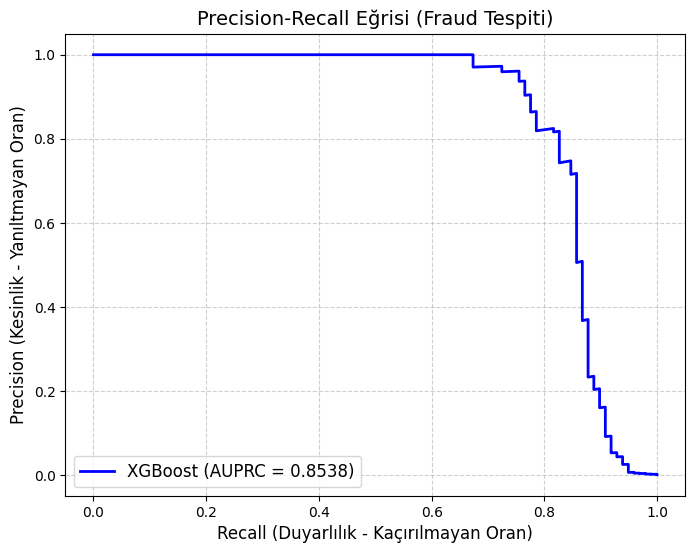

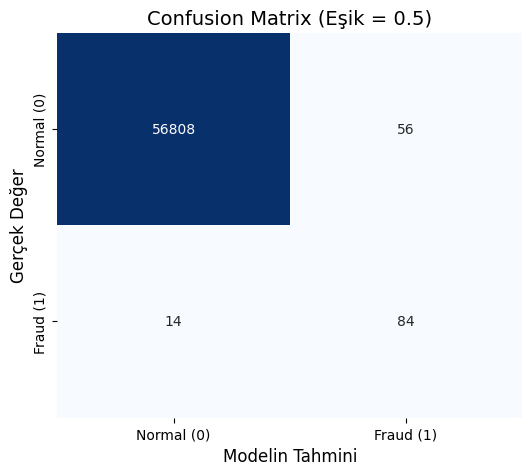

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, confusion_matrix, auc

# --- 1. GÖRSEL: Precision-Recall Eğrisi (AUPRC Görselleştirme) ---
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'XGBoost (AUPRC = {ap_score:.4f})')
plt.xlabel('Recall (Duyarlılık - Kaçırılmayan Oran)', fontsize=12)
plt.ylabel('Precision (Kesinlik - Yanıltmayan Oran)', fontsize=12)
plt.title('Precision-Recall Eğrisi (Fraud Tespiti)', fontsize=14)
plt.legend(loc='lower left', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- 2. GÖRSEL: Confusion Matrix (Karmaşıklık Matrisi) ---
# 0.5 eşik değerine göre tahmin edilen sınıflar
y_pred_custom = (y_pred_proba >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred_custom)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal (0)', 'Fraud (1)'],
            yticklabels=['Normal (0)', 'Fraud (1)'])
plt.xlabel('Modelin Tahmini', fontsize=12)
plt.ylabel('Gerçek Değer', fontsize=12)
plt.title('Confusion Matrix (Eşik = 0.5)', fontsize=14)
plt.show()